## Generete 2D and 3D model of human

In [ ]:
import sys
import os
sys.path.append(os.path.abspath('..'))

In [3]:
from anthropmass.mass.massmain_module import *
from anthropmass.prediction_module import *
from anthropmass.anthro_module import *
from anthropmass.mass.massmesh_module import *
from anthropmass.mass.measurements_heights_module import *
from anthropmass.mass.massurdf_module import *
import pandas as pd

In [6]:
def make_a_human(weight, height, gender):
    measurements=measurement_names()
    person = pd.DataFrame([{'weightkg': weight,'stature': height,'Gender': gender}])
    df = loop_measurements('xgboost',measurements, person)
    main(df, weight, height, gender)

RESULTS:
Estimated Height (m): 1.7702025175094604
Actual Height (m): 1.76
Total Estimated Weight (kg) using Clauser regression model 88.51884634905281
Total Estimated Weight (kg) using Zatriosky regression model 87.15112

Positions of Body Segments (Custom Cartesian Mapping)

    Head Upper Trunk Middle Trunk Lower Trunk Upper Arm Lower Arm   Hand  Thigh  Shank   Foot
X      0           0            0           0         0         0      0      0      0      0
Y      0           0            0           0     0.207     0.207  0.207  0.073  0.073  0.073
Z  1.648       1.368        1.182       0.981     1.278     0.996   0.79  0.725  0.322  0.036

Joint Center Positions

  Shoulder  Elbow  Wrist    Hip   Knee  Ankle
X        0      0      0      0      0      0
Y    0.207  0.207  0.207  0.102  0.073  0.073
Z    1.409  1.092  0.844  0.903  0.471   0.07
...................

Segment Mass Comparison (kg) — Detailed Trunk View

             Head Trunk Total Upper Trunk Middle Trunk Lower Trun

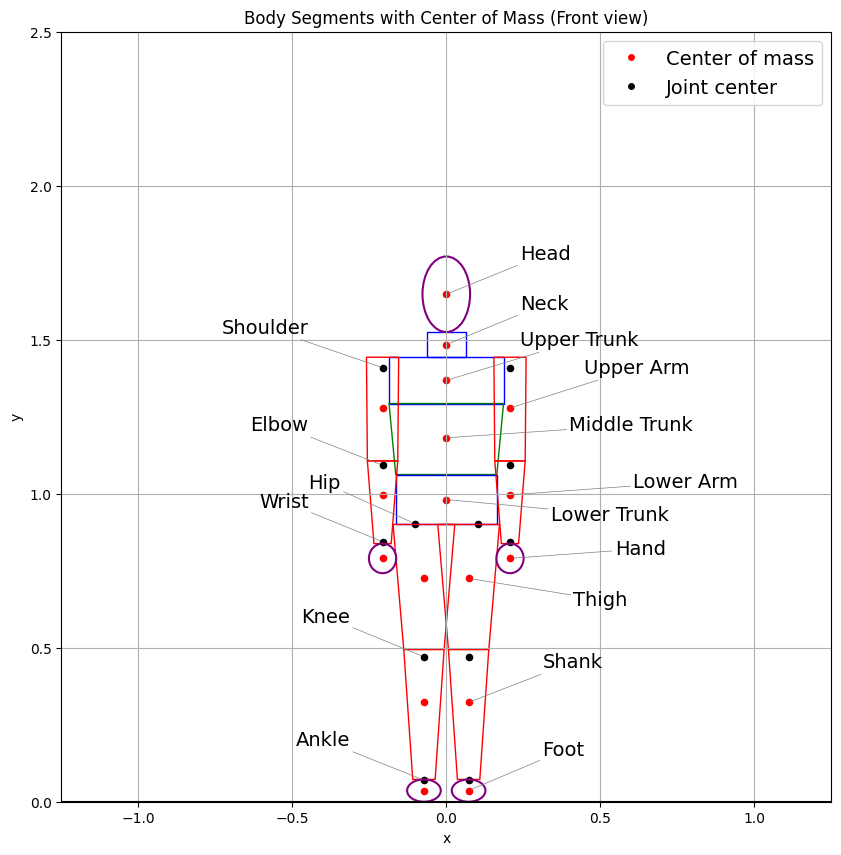

In [7]:
make_a_human(86,1760,1)

In [10]:
def generate_urdf_files(weight: int, height: int, gender: int):
    # 1) get the *raw* ANSUR row back out of your prediction
    measurements=measurement_names()
    persondf = pd.DataFrame([{'weightkg': weight,'stature': height,'Gender': gender}])
    person = loop_measurements('xgboost',measurements, persondf)

    # 2) compute just once for the meshes
    meas = get_measurements(person, height)

    # 3) write all the .stl’s
    generate_all_meshes(meas, height)
    print("Done")
    # 4) write the .urdf from the *raw* row, so it can call get_measurements again
    create_urdf(person, height)


In [14]:
generate_urdf_files(70,1900,0)

✅ Meshes exported to c:\Users\sanna\Desktop\kandidat\bsp_estimation\anthropmass\anthropmass\mass\model_output
Done
✅ URDF written
